<a href="https://colab.research.google.com/github/marisolmtzp/conectatel-analisys/blob/main/connectatel_analisys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
# En JupyterNotebooks - - - - - - - - - - - - - - - - - - - - -
#plans = pd.read_csv('/datasets/plans.csv')
#users = pd.read_csv('/datasets/users_latam.csv')
#usage = pd.read_csv('/datasets/usage.csv')
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# 1. Montar Google Drive (solo se ejecuta una vez por sesión)
from google.colab import drive
drive.mount('/content/drive')

# 2. Leer los CSV con la ruta correcta
import pandas as pd

plans = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/plans.csv')
users = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/users_latam.csv')
usage = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/usage.csv')


Mounted at /content/drive


In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


 **DIAGNÓSTICO**



**Users:**
- `city` tiene 469 nulos de 4,000 registros -> **11.73%** ---- No debería haber nulos. **Se comprobó MCAR, ausentes aleatorios, no pertenecen a un segmento determinado** tal vez sea error de captura / registros corruptos. Recomendo investigar proceso de captura y en el caso de este análisis **IMPUTAR** con "unknown" para usarlo en la segmentación.
- `churn_date` tiene 3534 nulos de 4,000 registros -> **88.35%** ---- Un porcentaje alto de nulos es normal ya que se espera que sólo los usuarios que han abandonado (11.65%) tengan un registro en esta columna. **IGNORAR** (Transformar a una columna binaria si se necesita usar como feature)

**Usage:**
- `date` tiene 50 nulos de 40,000 registros -> **0.13%** ---- La fecha de un evento siempre debería existir, esto denota: error de captura o registros corruptos. **ELIMINAR o IGNORAR** si se eliminan, documentar la decisión.
- `duration` tiene 22,076 nulos de 40,000 registros -> **55.19%** ---- Patrón missingness MAR, su ausencia depende de la columna **type** si el valor es Call, hay registro en **duration** y NaN en **length**.  **IGNORAR**
- `length`  tiene 17,896 nulos de 40,000 registros -> **44.74%** ---- Patrón missingness MAR, su ausencia depende de la columna **type** si el valor es Text, hay registro en **length** y NaN en **duration**.  **IGNORAR**


---

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

print (f"\nSentinel -999 en age: {users['age'].isin([-999]).sum()}", f"({users['age'].isin([-999]).mean()*100}%)")

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Sentinel -999 en age: 55 (1.375%)


---
 **DIAGNÓSTICO**
 - La columna `user_id` no presenta anomalías — rango secuencial continuo de 10,000 a 13,999, sin duplicados, sin huecos y sin valores fuera de rango.
 - La columna `age` presenta 55 valores centinela -999 (1.375% del total), se recomienda **IMPUTAR** con mediana.

---

In [14]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id','duration','length']].describe())


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000



---
 **DIAGNÓSTICO**

 - Las columnas `id` y `user_id`no presentan anomalías, id con secuencia continua (1,40000) sin duplicados ni huecos.
 - Las columnas `duration` y `length`:\
 -- La suma de su conteo es 17924 + 22104 =  40028.  El análisis anterior arrojó que son excluyentes, por lo que se intuye una superposición de ambos valores en 28 registros (podría investigarse si esto es correcto o se trata de registros corruptos). **IGNORAR** hasta que no se compruebe error.\
 -- Revisar si el valor mínimo 0 en ambas columnas es válido, ya que se trata de llamadas sin audio o mensajes sin texto que se cobraron, bajo qué condiciones. **IGNORAR** hasta que no se compruebe error.

---

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

print("\nDetalle city:\n", users['city'].value_counts(),sep="")

print("\nDetalle plan:\n", users['plan'].value_counts(), sep="")
print (f"\nSentinel ? en city: {(users['city'] == '?').sum()}", f"({(users['city'] == '?').mean()*100}%)")

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Detalle city:
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Detalle plan:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64

Sentinel ? en city: 96 (2.4%)



---
 **DIAGNÓSTICO**

 - La columna `city`:\
 -- presenta 96 sentinels '?' 2.4% del total, recomiendo **IMPUTAR** con NaN; y ya que presenta 469 nulos de 4,000 registros (11.73%), el missing total 565 (14.12%) podría ser **IMPUTADO** de NaN a "unknown" para usarlo en segmentación.
 - La columna `plan` no presenta anomalías: 2 valores únicos (Basico, Premium), sin NaN ni sentinels.

---

In [16]:
# explorar columna categórica de usage
print(usage['type'].describe())

print("\nDetalle type:\n", usage['type'].value_counts(), sep="")

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Detalle type:
type
text    22092
call    17908
Name: count, dtype: int64


---
 **DIAGNÓSTICO**
 - La columna `type` no presenta anomalías, 2 valores únicos (text, call), sin NaN ni sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**DIAGNÓSTICO VALORES INVÁLIDOS Y SENTINELS**


  - columna `age`: **IMPUTAR** con Mediana 55 valores sentinels -999 (1.375%).
  - columna `city`: **IMPUTAR** a NaN 96 sentinels '?' (2.4%) para unificarlo con los 469 (11.73%) NaN existentes, el missing total 565 (14.12%) se recomienda **IMPUTARLO** de NaN a "unknown"

---

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [19]:
# Revisar los años presentes en `reg_date` de users
print("Años presentes en users:\n", users['reg_date'].dt.year.value_counts(), sep="")

Años presentes en users:
reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


En `reg_date` anomalía detectada: 40 registros con año 2026 — fuera del período esperado (hasta 2024).

In [20]:
# Revisar los años presentes en `date` de usage
print("\nAños presentes en usage:\n", usage['date'].dt.year.value_counts(), sep="")


Años presentes en usage:
date
2024.0    39950
Name: count, dtype: int64


En `date` todas las fechas en 2024 — rango válido y consistente con el período del análisis.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**DIAGNÓSTICO REVISIÓN DE FECHAS**
 - En `reg_date` el periodo (2022 - 2026) refleja altas históricas y recientes pero los 40 usuarios registrados en 2026 no tienen eventos en usage (corte temporal del análisis), así que se recomienda **IGNORAR** estos registros de 2026 (son datos válidos que simplemente quedan fuera del período analizado). Los registros de (2022 - 2024) son válidos por que los usarios se registraron previamente al corte temporal del análisis.

 - En `date` presenta fechas dentro de rango (recordar que presenta 50 NaT (0.13%) — por posible error de captura).


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace([-999], age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace(["?"], pd.NA)

# Verificar cambios
users['city'].describe()

,city
count,3435
unique,6
top,Bogotá
freq,808


In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

,duration
type,
text,0.999276
call,0.000000


In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

,length
type,
call,0.99933
text,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**DIAGNOSTICO**

Las columnas `duration` y `length` presentan missingness MAR en función de la columna `type` (se dejarán como nulos ya que son válidos):
 - Los registros correspodientes a llamadas **call** presentan dato en duration pero NaN en length por que describen la duración de la llamada.
 - Los registros correspondientes a mensajes **text** presentan dato en length pero NaN en duration por que describen la longitud del mensaje de texto.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id', dropna=False).agg({'is_text':'sum'}).reset_index()
usage_agg = usage.groupby('user_id', dropna=False).agg({
    'is_text'  : 'sum',
    'is_call'  : 'sum',
    'duration' : 'sum'
}).reset_index()

# usage_agg = usage.groupby("user_id").agg(
#    cant_mensajes        = ("is_text", "sum"),
#    cant_llamadas        = ("is_call", "sum"),
#    cant_minutos_llamada = ("duration", "sum")
#).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text'  : 'cant_mensajes',
    'is_call'  : 'cant_llamadas',
    'duration' : 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=['user_id','user_id'],how='inner')

user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
# users: age, city, reg_date, plan
# usage_agg: cant_mensajes, cant_llamadas, cant_minutos_llamada
# user_profile: user_id, cant_mensajes, cant_llamadas, cant_minutos_llamada, first_name, last_name, age, city, reg_date, plan, churn_date

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas','cant_minutos_llamada']
print('Resumen estadístico de las columnas numéricas:')

# print("Mediana: \n", user_profile[columnas_numericas].median())
# print(user_profile[columnas_numericas].describe())

desc = user_profile[columnas_numericas].describe()
desc.loc['median'] = user_profile[columnas_numericas].median()
print(desc)

Resumen estadístico de las columnas numéricas:
                age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count   3999.000000    3999.000000    3999.000000           3999.000000
mean      48.124531       5.524381       4.478120             23.317054
std       17.692032       2.358416       2.144238             18.168095
min       18.000000       0.000000       0.000000              0.000000
25%       33.000000       4.000000       3.000000             11.120000
50%       47.000000       5.000000       4.000000             19.780000
75%       63.000000       7.000000       6.000000             31.415000
max       79.000000      17.000000      15.000000            155.690000
median    47.000000       5.000000       4.000000             19.780000


In [30]:
# Distribución porcentual del tipo de plan

print("Frecuencia absoluta:")
print(user_profile['plan'].value_counts())

print("\nFrecuencia relativa:")
print(user_profile['plan'].value_counts(normalize=True))


Frecuencia absoluta:
plan
Basico     2594
Premium    1405
Name: count, dtype: int64

Frecuencia relativa:
plan
Basico     0.648662
Premium    0.351338
Name: proportion, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

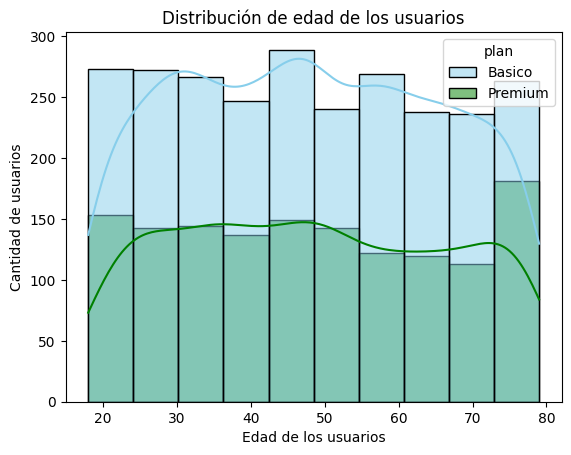

In [31]:
# Histograma para visualizar la edad (age)

#sns.histplot(user_profile['age'], bins=10, color='skyblue', kde=True)
sns.histplot(user_profile, x='age', bins=10, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad de los usuarios')
plt.show()

💡Insights:
- Distribución:\
  Uniforme de 18 a 79 sin concentración por grupo de edad\
  La proporción Basico/Premium es constante en todos los rangos de edad\
  La edad no parece ser un predictor relevante del plan contratado

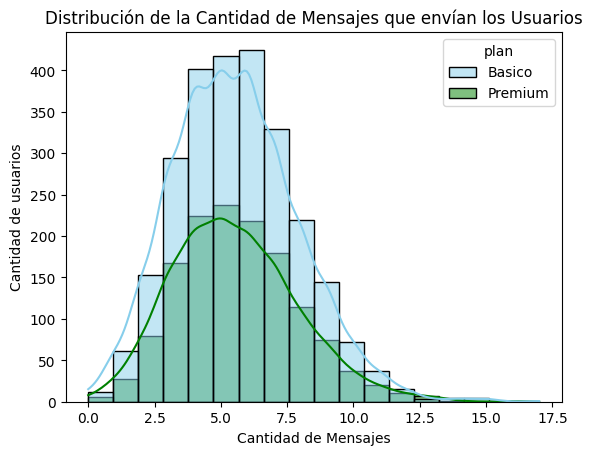

In [ ]:
# Histograma para visualizar la cant_mensajes

#sns.histplot(user_profile['cant_mensajes'], bins=10, color='skyblue', kde=True)
sns.histplot(user_profile, x='cant_mensajes', bins=18, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la Cantidad de Mensajes que envían los Usuarios')
plt.show()

💡Insights:
- Distribución:\
  Sesgada a la derecha en ambos planes (se aprecia mejor gracias a la línea KDE)\
  Concentración principal entre 2-8 mensajes\
  Outliers potenciales por encima de 12 hasta 17 (extremos en relación a llamadas y minutos) (marcado por el sesgo derecho)\
  Premium muestra comportamiento más homogéneo que Básico

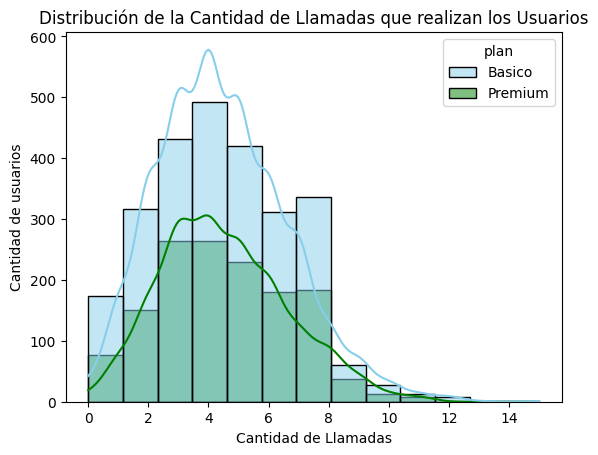

In [ ]:
# Histograma para visualizar la cant_llamadas

#sns.histplot(user_profile['cant_llamadas'], bins=10, color='skyblue', kde=True)
sns.histplot(user_profile, x='cant_llamadas', bins=13, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la Cantidad de Llamadas que realizan los Usuarios')
plt.show()

💡Insights:
- Distribución\
  Aproximadamente normal, ligero sesgo derecha (menos pronunciada que cant_mensajes)\
  Pico en 4 llamadas para ambos planes\
  Premium muestra mayor actividad en llamadas que Básico — consistente con el plan\
  Outliers moderados por encima de 10 hasta 14

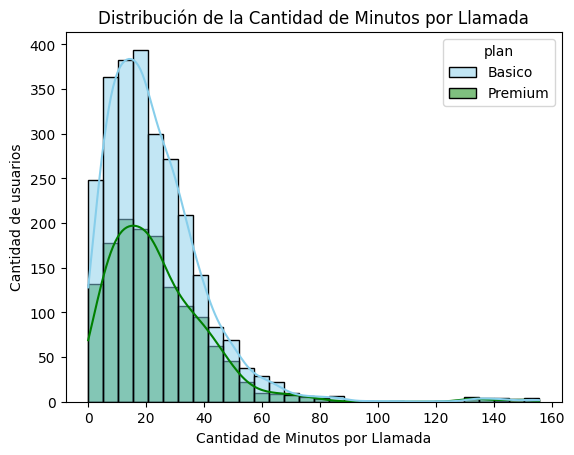

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

#sns.histplot(user_profile['cant_minutos_llamada'], bins=10, color='skyblue', kde=True)
sns.histplot(user_profile, x='cant_minutos_llamada', bins=30, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la Cantidad de Minutos por Llamada')
plt.show()

💡Insights:
- Distribución\
  Con sesgo pronunciado a la derecha\
  Plan Básico concentrado en 0-20 min, Premium más distribuido hasta 60 min\
  Es la variable con mayor diferenciación entre planes\
  Outliers por encima de 100 min y hasta 160 min — (extremos en relación a mensajes y cantidad de llamadas) evaluar si son uso legítimo o error de datos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

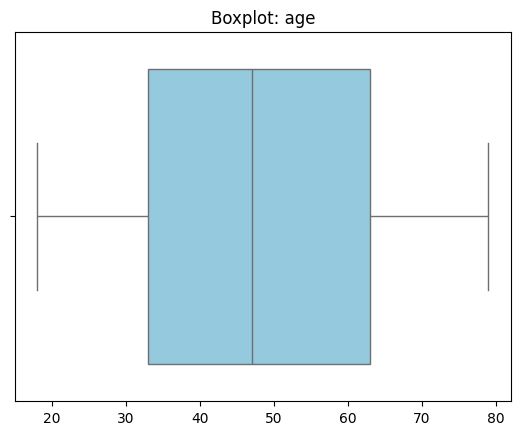

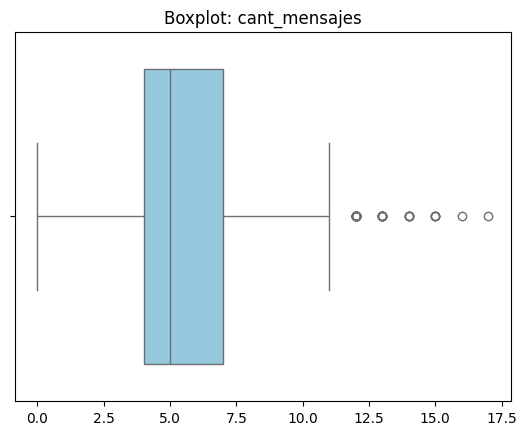

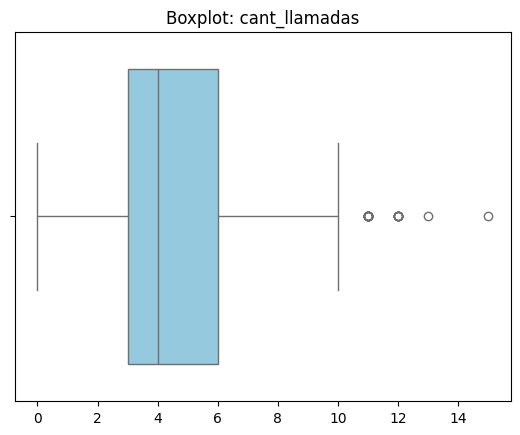

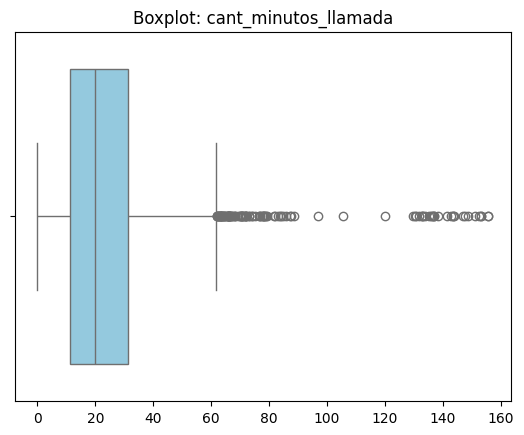

In [32]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('')
    plt.show()

# user_profile['age'].describe()
# user_profile['cant_mensajes'].describe()
# user_profile['cant_llamadas'].describe()
# user_profile['cant_minutos_llamada'].describe()

💡Insights:

- **Age**: No presenta outliers, los bigotes llegan hasta los extremos naturales del rango (18-79) y la caja es amplia y simétrica.
- **cant_mensajes**: Presenta outliers, 6 puntos aislados entre 12.5 y 17, claramente fuera del bigote derecho. Son pocos pero consistentes con el sesgo derecho del histograma.
- **cant_llamadas**: Presenta outliers, se observan 4 puntos aislados entre 11 y 15, fuera del bigote derecho. Similar a mensajes pero menos extremos.
- **cant_minutos_llamada**: Es el más crítico, presenta una nube densa de outliers desde ~65 hasta 155 minutos. No son puntos aislados sino un conjunto numeroso y disperso, lo que sugiere que no son errores sino usuarios con comportamiento de consumo alto pero real. El bigote derecho ya termina alrededor de 65 y todo lo que sigue es outlier.


In [33]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR

    print(f"Outliers en {col} (IQR: {IQR}), (Upper:{upper})")
    #display(user_profile[(user_profile[col] > upper) | (user_profile[col] < lower)])
    display(user_profile[(user_profile[col] > upper)])


Outliers en age (IQR: 30.0), (Upper:108.0)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date


Outliers en cant_mensajes (IQR: 3.0), (Upper:11.5)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
315,10315,13,3,12.36,Carlos,Lopez,30,MTY,2022-03-28 06:04:03.060765192,Basico,NaN
347,10347,13,3,21.40,Carlos,Garcia,77,Cali,2022-04-06 00:21:36.324081021,Basico,NaN
356,10356,12,5,59.48,Mateo,Garcia,42,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN
384,10384,12,3,13.05,Sofia,Ramirez,35,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN
456,10456,12,1,2.24,Mateo,Ramirez,47,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18"
539,10539,14,5,8.66,Sofia,Ramirez,77,Cali,2022-05-28 14:06:55.903975994,Basico,NaN
591,10591,12,2,16.52,Ana,Gomez,25,NaN,2022-06-11 19:50:27.456864216,Basico,NaN
670,10670,12,3,19.13,Carlos,Torres,47,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN
903,10903,12,3,8.89,Carlos,Lopez,63,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18"
908,10908,14,3,12.50,Mariana,Lopez,56,MTY,2022-09-06 15:03:06.346586648,Basico,NaN


Outliers en cant_llamadas (IQR: 3.0), (Upper:10.5)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
116,10116,3,11,44.32,Ana,Garcia,52,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN
417,10417,4,12,26.42,Luis,Garcia,70,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN
777,10777,4,12,55.28,Sofia,Lopez,65,Cali,2022-08-01 18:09:59.549887472,Basico,NaN
778,10778,8,11,32.13,Mateo,Lopez,77,NaN,2022-08-02 00:44:17.464366092,Basico,NaN
862,10862,4,15,78.11,Luis,Ramirez,23,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN
1013,11013,4,11,60.83,Mateo,Lopez,65,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN
1563,11564,8,11,30.17,Carlos,Lopez,41,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN
1613,11614,5,11,41.80,Mateo,Garcia,73,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN
1911,11912,2,11,65.71,Mariana,Garcia,48,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN
2012,12013,2,12,65.55,Mateo,Lopez,48,GDL,2023-07-06 04:43:01.845461368,Basico,NaN


Outliers en cant_minutos_llamada (IQR: 20.295), (Upper:61.8575)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
27,10027,8,7,84.77,Ana,Gomez,28,MTY,2022-01-08 09:26:03.690922730,Premium,NaN
85,10085,6,5,152.36,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN
93,10093,2,7,71.57,Ana,Torres,67,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN
189,10189,9,4,155.42,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN
198,10198,8,9,78.77,Sofia,Gomez,58,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18"
...,...,...,...,...,...,...,...,...,...,...,...
3919,13920,4,5,132.72,Mariana,Lopez,48,Bogotá,2024-12-09 08:50:24.756189056,Premium,NaN
3926,13927,8,4,135.96,Mariana,Lopez,18,GDL,2024-12-11 06:50:30.157539392,Basico,"1,72549E+18"
3944,13945,7,3,133.97,Luis,Ramirez,30,Bogotá,2024-12-16 05:07:52.618154544,Basico,NaN
3952,13953,0,7,155.69,Mateo,Gomez,58,GDL,2024-12-18 09:42:15.933983504,Basico,NaN


In [34]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

#      user_profile[columnas_limites].describe()
desc = user_profile[columnas_limites].describe()
desc.loc['IQR']   = user_profile[columnas_limites].quantile(0.75) - user_profile[columnas_limites].quantile(0.25)
desc.loc['upper'] = user_profile[columnas_limites].quantile(0.75) + 1.5 * desc.loc['IQR']
print(desc)

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  3999.000000    3999.000000    3999.000000           3999.000000
mean     48.124531       5.524381       4.478120             23.317054
std      17.692032       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000
IQR      30.000000       3.000000       3.000000             20.295000
upper   108.000000      11.500000      10.500000             61.857500


💡Insights:
- **cant_mensajes**: MANTENER - Upper(11.5), max(17) - **USUARIOS CONSUMO ALTO**: hay valores fuera del límite pero son pocos y representan usuarios que simplemente mandan muchos mensajes (un usuario con 17 mensajes es completamente posible).
- **cant_llamadas**: MANTENER - Upper(10.5), max(15) - **USUARIOS MUY ACTIVOS**: hay valores fuera del límite pero pocos (un usuario con 14 llamadas en 6 meses es normal).   El IQR es pequeño hace que el límite sea conservador, no que los valores sean raros.
- **cant_minutos_llamada**: MANTENER CON PRECAUCION (sólo eliminar si se confirma que son errores de captura).  Upper(61.8), max(155.6) - **USUARIOS PREMIUM CON MUCHOS MINUTOS**: la nube de outliers es numerosa y extendida.  Pero recordar que Premium (según el dataset plans) tiene 600 minutos incluidos (un usuario Premium con 120 minutos en 6 meses es perfectamente válido) La distribución sesgada es inherente al negocio, no un error.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [35]:
# Crear columna grupo_uso
def clasificar_uso(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']
    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en Datos"
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [36]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [37]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']
    if pd.isna(edad):
        return "Error en Datos"
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [38]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

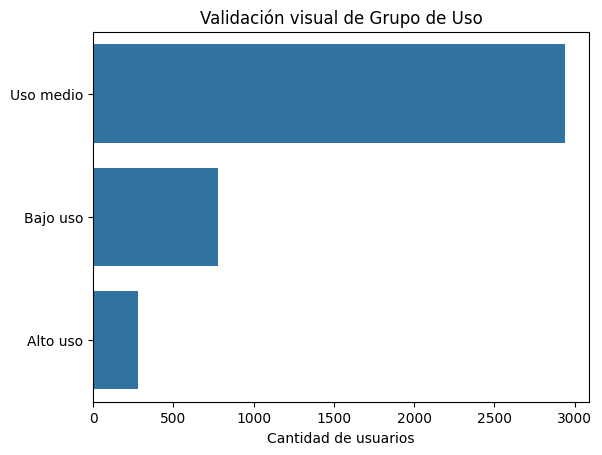

In [39]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title(f'Validación visual de Grupo de Uso')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('')
plt.show()

#print(user_profile['grupo_uso'].value_counts())
#print(user_profile['grupo_uso'].value_counts(normalize=True))

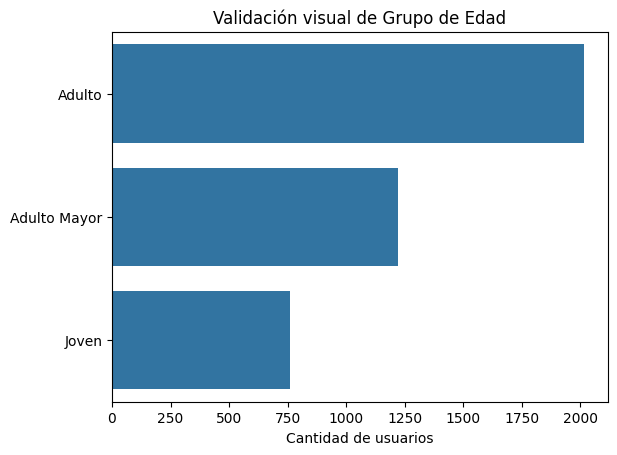

In [40]:
# Visualización de los segmentos por edad
grupo='grupo_edad'

sns.countplot(data=user_profile, y='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title(f'Validación visual de Grupo de Edad')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('')
plt.show()

#print(user_profile['grupo_edad'].value_counts())
#print(user_profile['grupo_edad'].value_counts(normalize=True))


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

Pregunta 1 — ¿Qué problemas tenían originalmente los datos?\
⚠️ **Problemas detectados en los datos**
 - **Tabla users (4,000 registros):**\
   `age`: 55 valores sentinel -999 (1.38%) edades desconocidas, **se imputaron a Mediana**.\
   `city`: 469 NaN reales (11.72%) + 96 sentinels "?" (2.40%) **que se imputaron a NaN** = 565 missing totales (14.12%).\
    Diagnóstico MCAR — el missing es aleatorio, sin patrón asociado a plan, churn ni edad.\
    `churn_date`: 3,534 NaN (88.35%) — normal y esperado, solo registra la fecha cuando el usuario abandonó.\
    `reg_date`: 40 registros con fecha 2026 — fuera del período de análisis (ene–jun 2024), sin eventos en usage **se imputaron a NaT**.

 - **Tabla usage (40,000 registros):**\
  `duration`: 22,076 nulos (55.19%), patrón missingness MAR, su ausencia depende de la columna **type** si el valor es Call, hay registro en **duration** y NaN en **length**.\
  `length`: 17,896 nulos (44.74%), patrón missingness MAR, su ausencia depende de la columna **type** si el valor es Text, hay registro en **length** y NaN en **duration**.\
  `date`: 50 NaT (0.13%) — posible error de captura, se ignoraron por volumen insignificante.\


➡️ La calidad general es buena — los problemas fueron localizados, identificados y corregidos sin pérdida significativa de información.

Pregunta 2 — ¿Qué segmentos identificados y cómo se comportan?\
🔍 **Segmentos por Edad**
 - La distribución de edad es uniforme entre 18 y 79 años — sin concentración en ningún grupo etario.
 - La proporción Básico/Premium se mantiene constante en todos los rangos de edad — la edad no determina la elección del plan.
 - Tres grupos naturales: Jóvenes (18–29: 19%), Adultos (30–59: 50.4%), Adultos Mayores (60–79: 30.55%) con tamaños que no muestran grandes diferencias.

📊 **Segmentos por Nivel de Uso**
 - Bajo uso (19.4%) (llamadas < 5 y mensajes < 5): usuarios con consumo mínimo, probablemente en riesgo de churn.
 - Uso medio (73.6%) (llamadas < 10 y mensajes < 10): el segmento más numeroso, consumo dentro del rango del plan Básico.
 - Alto uso (7%) (resto): usuarios heavy users, candidatos naturales a Premium o planes superiores.

➡️ Esto sugiere que ConnectaTel tiene una base diversa en edad pero homogénea en comportamiento — el nivel de uso es el verdadero diferenciador entre segmentos, no la demografía.

Pregunta 3 — ¿Qué segmentos son más valiosos?\
🔍 **Segmentos por Edad**
 - Ningún grupo etario destaca por sí solo — la uniformidad indica que todos los rangos de edad son igualmente relevantes para la base de clientes.

📊 **Segmentos por Nivel de Uso**
 - **Alto uso en plan Básico** — el segmento más valioso de inmediato: usuarios que ya superan los 100 minutos o 100 mensajes incluidos y están pagando excedentes a 10 centavos/min y 8 centavos/msg. Son candidatos directos a upgrade a Premium.
 - **Usuarios Premium activos** — ya generan \$25 por mes con menor costo por excedente. Su mayor consumo de minutos (pico en 20 min vs 0–10 de Básico) confirma que usan el plan correctamente.
 - **Bajo uso en Premium** — segmento en riesgo de downgrade o cancelación: pagan \$25 pero no aprovechan los 600 minutos ni 500 mensajes incluidos.

➡️ Esto sugiere que la mayor oportunidad de ingreso está en convertir usuarios de Alto uso en Básico a Premium, y en retener usuarios Premium activos evitando que migren a Básico.

Pregunta 4 — ¿Qué patrones de uso extremo encontraste?\
⚠️ **Outliers detectados**
 - cant_mensajes: ~7 puntos, usuarios con más de 12 mensajes upper(11.5), max(17) — pocos, aislados, comportamiento real. (normal, CONSUMO ALTO).
 - cant_llamadas: ~4 puntos, usuarios con más de 11 llamadas upper(10.5), max(15) — moderados, comportamiento real (normal, USUARIOS MUY ACTIVOS).
 - cant_minutos_llamada: nube densa de usuarios entre 65 y 160 minutos (upper(61.8), max(155.6) — el más crítico en volumen (normal, USUARIOS PREMIUM CON MUCHOS MINUTOS).

📊 **Qué implican para el negocio**
 - Los outliers de minutos no son errores — son usuarios heavy users, especialmente Premium con 600 minutos disponibles.
 - Un usuario Básico con 150 minutos está pagando excedentes significativos: 50 minutos extra × 10 centavos = 5 monedas adicionales al mes sobre su cuota de 12 monedas.
 - Estos usuarios Básicos generan ingresos por excedente pero también tienen mayor riesgo de churn por percepción de costo elevado.

➡️ Esto sugiere que los outliers de consumo son una señal comercial, no un problema de datos — identifican a los usuarios más rentables y más sensibles al precio al mismo tiempo.


Pregunta 5 — ¿Qué recomendaciones harías?\
💡 **Recomendaciones: Basadas en los segmentos y patrones detectados**
 - Crear un plan intermedio para capturar el segmento de Uso medio que no justifica Premium pero ya está superando Básico.
 - Campaña de upgrade dirigida a usuarios Básico con cant_minutos_llamada > 60 — ya están pagando excedentes, un mensaje personalizado mostrando su ahorro potencial con Premium tendría alta conversión.
 - Programa de retención para Premium de bajo uso — ofrecerles beneficios adicionales (más GB, descuentos) para justificar el costo y reducir riesgo de downgrade.
 - Revisar la captura de city — el 14.12% de missing impide segmentación geográfica. Implementar campo obligatorio en el registro o enriquecer con geolocalización del dispositivo.
 - Estandarizar sentinles en el pipeline de datos — los valores -999, "?", (y valores tope en 'duration' y 'length') indican que distintos sistemas usan convenciones diferentes. Un diccionario de datos centralizado evitaría estos problemas en futuros análisis.

💡 **Conclusión ejecutiva**
ConnectaTel tiene una base de clientes saludable y diversa, con datos suficientemente limpios para tomar decisiones. La mayor oportunidad está en la brecha entre planes — hay usuarios que ya se comportan como Premium pero siguen pagando como Básico, y eso representa tanto ingresos no capturados como riesgo de churn (abadono) por insatisfacción con el costo de excedentes.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/marisolmtzp/conectatel-analisys